In diesem Notebook werden die Daten geladen und zur Übersicht dargestellt

In [9]:
import pandas as pd
import numpy as np

Hier rohen Datensatz initialisieren

In [10]:
# Datensatz laden
df = pd.read_json("../data/mobile_game_inapp_purchases.json", lines=True)

# Überblick
print(df.shape)
display(df.head())
display(df.info())
display(df.describe(include="all"))

# Fehlende Werte
missing = df.isna().sum().sort_values(ascending=False)
display(missing)

# Eindeutige Werte pro Spalte
unique_values = df.nunique().sort_values(ascending=False)
display(unique_values)

(3024, 13)


,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,1.742342e+12
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,1.749341e+12
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,1.748822e+12
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,1.743466e+12
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,1.746403e+12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   UserID                         3024 non-null   object 
 1   Age                            2964 non-null   float64
 2   Gender                         2964 non-null   object 
 3   Country                        2964 non-null   object 
 4   Device                         2964 non-null   object 
 5   GameGenre                      2964 non-null   object 
 6   SessionCount                   3024 non-null   int64  
 7   AverageSessionLength           3024 non-null   float64
 8   SpendingSegment                3024 non-null   object 
 9   InAppPurchaseAmount            2888 non-null   float64
 10  FirstPurchaseDaysAfterInstall  2888 non-null   float64
 11  PaymentMethod                  2888 non-null   object 
 12  LastPurchaseDate               2888 non-null   f

None

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate
count,3024,2964.000000,2964,2964,2964,2964,3024.000000,3024.000000,3024,2888.000000,2888.000000,2888,2.888000e+03
unique,3024,NaN,3,27,2,15,NaN,NaN,3,NaN,NaN,7,NaN
top,aa244cd4-8752-45d9-82b2-4a3f71c5d47b,NaN,Male,India,Android,Simulation,NaN,NaN,Minnow,NaN,NaN,Debit Card,NaN
freq,1,NaN,1810,242,1738,219,NaN,NaN,2544,NaN,NaN,433,NaN
mean,NaN,33.533738,NaN,NaN,NaN,NaN,10.074735,20.073978,NaN,102.582864,15.384003,NaN,1.745512e+12
std,NaN,11.992258,NaN,NaN,NaN,NaN,3.115863,8.585208,NaN,454.339708,8.946191,NaN,5.591207e+09
min,NaN,13.000000,NaN,NaN,NaN,NaN,1.000000,5.010000,NaN,0.000000,0.000000,NaN,1.735690e+12
25%,NaN,23.000000,NaN,NaN,NaN,NaN,8.000000,12.680000,NaN,5.987500,8.000000,NaN,1.740701e+12
50%,NaN,33.000000,NaN,NaN,NaN,NaN,10.000000,20.315000,NaN,11.975000,16.000000,NaN,1.745626e+12
75%,NaN,44.000000,NaN,NaN,NaN,NaN,12.000000,27.420000,NaN,17.762500,23.000000,NaN,1.750378e+12


LastPurchaseDate                 136
InAppPurchaseAmount              136
FirstPurchaseDaysAfterInstall    136
PaymentMethod                    136
Age                               60
GameGenre                         60
Device                            60
Gender                            60
Country                           60
UserID                             0
SpendingSegment                    0
SessionCount                       0
AverageSessionLength               0
dtype: int64

UserID                           3024
AverageSessionLength             1915
InAppPurchaseAmount              1839
LastPurchaseDate                  225
Age                                42
FirstPurchaseDaysAfterInstall      31
Country                            27
SessionCount                       21
GameGenre                          15
PaymentMethod                       7
Gender                              3
SpendingSegment                     3
Device                              2
dtype: int64

Zielvariablen testen

In [11]:
# Variante A: Hat der Nutzer gekauft?
df["MadePurchase"] = df["InAppPurchaseAmount"].fillna(0).gt(0).astype(int)

# Variante B: Ist der Nutzer ein zahlungsstarker Nutzer?
df["HighSpender"] = df["SpendingSegment"].isin(["Dolphin", "Whale"]).astype(int)

# Verteilungen prüfen
print("MadePurchase:")
print(df["MadePurchase"].value_counts())
print(df["MadePurchase"].value_counts(normalize=True))

print("\nHighSpender:")
print(df["HighSpender"].value_counts())
print(df["HighSpender"].value_counts(normalize=True))

MadePurchase:
MadePurchase
1    2887
0     137
Name: count, dtype: int64
MadePurchase
1    0.954696
0    0.045304
Name: proportion, dtype: float64

HighSpender:
HighSpender
0    2544
1     480
Name: count, dtype: int64
HighSpender
0    0.84127
1    0.15873
Name: proportion, dtype: float64


Visualisierung

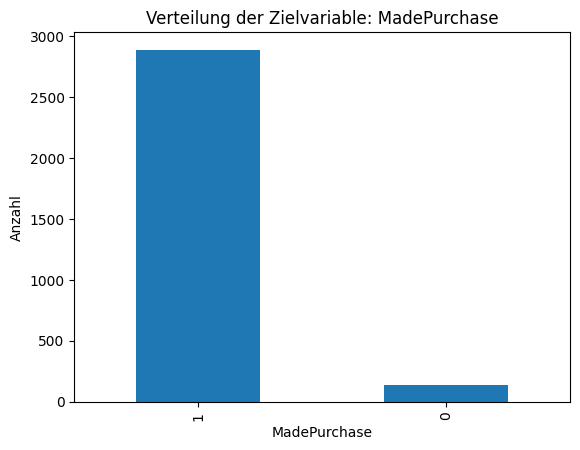

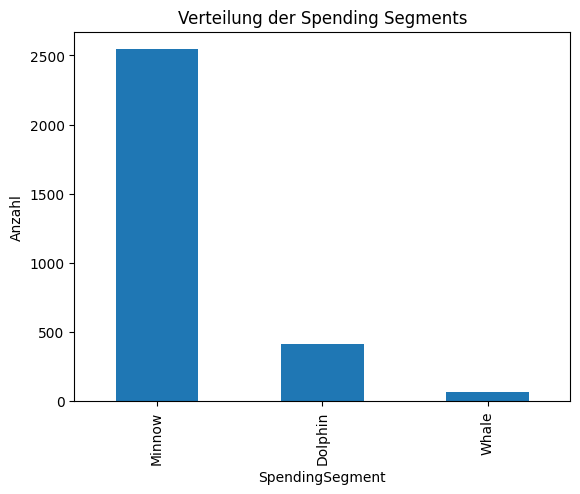

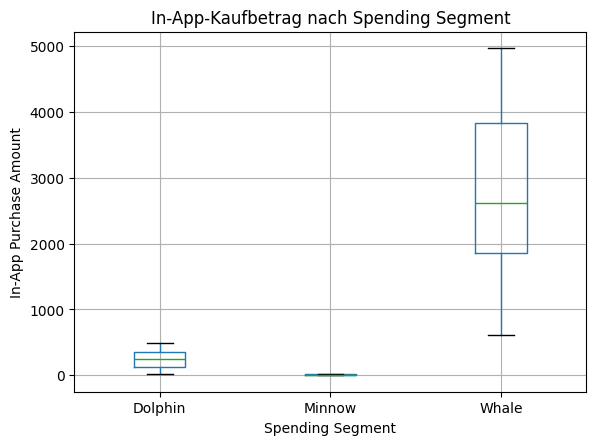

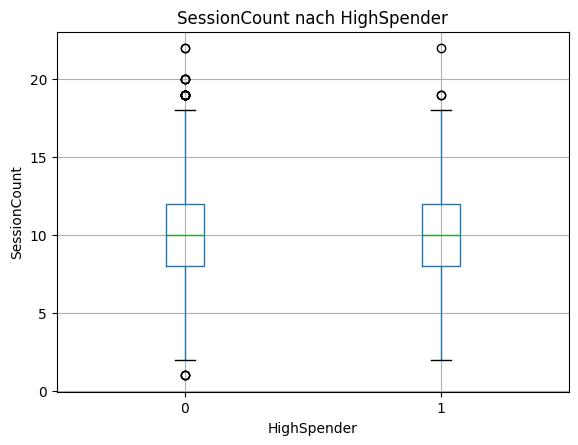

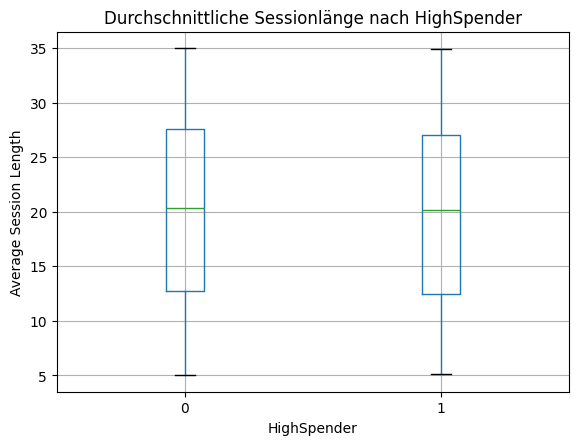

In [12]:
import matplotlib.pyplot as plt

# Zielvariable: Käufer vs Nicht-Käufer
df["MadePurchase"].value_counts().plot(kind="bar")
plt.title("Verteilung der Zielvariable: MadePurchase")
plt.xlabel("MadePurchase")
plt.ylabel("Anzahl")
plt.show()

# Spending Segments
df["SpendingSegment"].value_counts().plot(kind="bar")
plt.title("Verteilung der Spending Segments")
plt.xlabel("SpendingSegment")
plt.ylabel("Anzahl")
plt.show()

# Kaufbetrag nach Spending Segment
df.boxplot(column="InAppPurchaseAmount", by="SpendingSegment")
plt.title("In-App-Kaufbetrag nach Spending Segment")
plt.suptitle("")
plt.xlabel("Spending Segment")
plt.ylabel("In-App Purchase Amount")
plt.show()

# SessionCount nach HighSpender
df.boxplot(column="SessionCount", by="HighSpender")
plt.title("SessionCount nach HighSpender")
plt.suptitle("")
plt.xlabel("HighSpender")
plt.ylabel("SessionCount")
plt.show()

# AverageSessionLength nach HighSpender
df.boxplot(column="AverageSessionLength", by="HighSpender")
plt.title("Durchschnittliche Sessionlänge nach HighSpender")
plt.suptitle("")
plt.xlabel("HighSpender")
plt.ylabel("Average Session Length")
plt.show()

df.to_pickle("readData.pkl")  # Speichern für schnelleren Zugriff in späteren Schritten 